In [1]:
# Libraries
import pandas as pd
import numpy as np

# CPU Cores & System
import os
import sys
import psutil

# Jalankan ini hanya jika posisi aktif masih di dalam folder notebooks
if os.getcwd().endswith('notebooks'):
    %cd ..

# Scipy
from scipy.stats import (
    chi2_contingency, 
    ks_2samp, spearmanr
)

# Viz libraries
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline

# Plotting options
%matplotlib inline
mpl.style.use('ggplot')
sns.set(style='whitegrid')

# Import warnings
import warnings
warnings.filterwarnings('ignore')

# Pandas set_option
pd.set_option('display.max_columns', None)

/home/gontommuhammad/credit_risk_modeling


<br>

---
# **Data Preparation:**

In [2]:
from src.utils import importData

# Define data path
data_path = 'data/raw/loan_data_2007_2014.csv'

df = importData(data_path)

df.head()

Origin Data Shape: (466285, 75) - (# Observation, # Column)

...handling duplicate data:
Sum of duplicate data: 0
Shape of duplicated rows: (0, 75)

Before drop rows: (466285, 75)
After drop rows: (466285, 75)


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df = df[sorted(df.columns)].set_index('member_id')

# Check if the index is unique
print(f"Is the index unique? {df.index.is_unique}")

df.info()

Is the index unique? True
<class 'pandas.DataFrame'>
Index: 466285 entries, 1296599 to 11061576
Data columns (total 74 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   acc_now_delinq               466256 non-null  float64
 2   addr_state                   466285 non-null  str    
 3   all_util                     0 non-null       float64
 4   annual_inc                   466281 non-null  float64
 5   annual_inc_joint             0 non-null       float64
 6   application_type             466285 non-null  str    
 7   collection_recovery_fee      466285 non-null  float64
 8   collections_12_mths_ex_med   466140 non-null  float64
 9   delinq_2yrs                  466256 non-null  float64
 10  desc                         125981 non-null  str    
 11  dti                          466285 non-null  float64
 12  dti_joint                    0 non-null 

<br>

From the EDA results, we need to drop *NaN* on the two datetime columns to produce `credit_history_age_month` → `_years` → `_group`. In production, `issue_d` is replaced with today's date when the user clicks "Apply" `todays_date = pd.Timestamp.now()`

In [4]:
date_columns = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'last_credit_pull_d']

df = df.dropna(subset=date_columns)

# IMPORTANT WARNING: Before entering the data preprocessing, 
# make sure the date column has been converted to date and time format 
# because the `binning_v3.py` module or the data binning process requires it.

print(f"Fixed date format and year anomalies...")
# Convert to datetime & fix "future" year simultaneously (Vectorization)
for col in date_columns:
    # Let Pandas guess the %b-%y format (e.g., Jan-14, Dec-68)
    df[col] = pd.to_datetime(df[col], format='%b-%y', errors='coerce')
    
    # Correction if the year jumps into the future (beyond the anchor year 2016)
    # Pandas automatically detects the year '68' as '2068', we change it to '1968'
    future_mask = df[col].dt.year > 2016
    df.loc[future_mask, col] = df.loc[future_mask, col] - pd.DateOffset(years=100)

print(f"Date format successfully corrected!")

Fixed date format and year anomalies...
Date format successfully corrected!


---
### Vintage Analysis:

In [5]:
# Extract quarterly periods (e.g., 2014Q1, 2014Q2, etc.) as vintage representations
vintage_quarter = df['issue_d'].dt.to_period('Q')

# Calculate the percentage distribution of loan_status per quarter (Main Verification Table)
status_dist_pct = pd.crosstab(
    vintage_quarter,
    df['loan_status'],
    normalize='index') * 100

# Calculate the total number of data points (to ensure the sample size is stable)
status_dist_count = pd.crosstab(vintage_quarter, df['loan_status'])

print(f"=== LOAN STATUS DISTRIBUTION BY QUARTERLY VINTAGE (%) ===")
display(status_dist_pct.round(2))

print(f"\n=== NOMINAL TOTAL DATA PER VINTAGE QUARTER ===")
status_dist_count

=== LOAN STATUS DISTRIBUTION BY QUARTERLY VINTAGE (%) ===


loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
issue_d,,,,,,,,,
2007Q2,0.00,0.00,0.00,0.00,66.67,33.33,0.00,0.00,0.00
2007Q3,5.52,0.00,0.00,16.57,38.67,39.23,0.00,0.00,0.00
2007Q4,9.02,0.00,0.00,20.62,36.08,34.28,0.00,0.00,0.00
2008Q1,9.50,0.00,0.00,13.45,29.08,47.97,0.00,0.00,0.00
2008Q2,8.84,0.00,0.00,13.25,28.11,49.80,0.00,0.00,0.00
2008Q3,9.40,0.00,0.00,8.05,29.53,53.02,0.00,0.00,0.00
2008Q4,13.38,0.00,0.00,3.60,10.29,72.73,0.00,0.00,0.00
2009Q1,10.39,0.00,0.00,3.35,10.06,76.20,0.00,0.00,0.00
2009Q2,11.15,0.00,0.00,2.93,9.14,76.78,0.00,0.00,0.00



=== NOMINAL TOTAL DATA PER VINTAGE QUARTER ===


loan_status,Charged Off,Current,Default,Does not meet the credit policy. Status:Charged Off,Does not meet the credit policy. Status:Fully Paid,Fully Paid,In Grace Period,Late (16-30 days),Late (31-120 days)
issue_d,,,,,,,,,
2007Q2,0,0,0,0,2,1,0,0,0
2007Q3,10,0,0,30,70,71,0,0,0
2007Q4,35,0,0,80,140,133,0,0,0
2008Q1,96,0,0,136,294,485,0,0,0
2008Q2,44,0,0,66,140,248,0,0,0
2008Q3,28,0,0,24,88,158,0,0,0
2008Q4,78,0,0,21,60,424,0,0,0
2009Q1,93,0,0,30,90,682,0,0,0
2009Q2,122,0,0,32,100,840,0,0,0


<br>

---
Addressing three problematic features in the Population Stability Index analysis process:

In [6]:
from src.utils import missing_summary

missing_summary(df[['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']])

,Missing Values,Percentage,Total length
tot_coll_amt,70130,15.05,465839
tot_cur_bal,70130,15.05,465839
total_rev_hi_lim,70130,15.05,465839


<br>

**Data Quality Analysis & Temporal Leakage**
>
>
> Based on an initial examination of the raw data, three features were found to have precisely identical missing values: `tot_coll_amt`, `tot_cur_bal`, and `total_rev_hi_lim`, each missing **66,660 rows** of data (**27.54%** of the total population).
> To validate this data loss pattern, a Vintage Analysis (analysis based on the loan issuance year `issue_d`) was performed. The test results revealed the following data loss structure:
> 1. **Old Historical Period (2007–2011):** All three features had a missing rate of 100%. This demonstrates a structural artifact in that LendingClub did not collect or integrate these financial metrics into its reporting system prior to 2012.
> 2. **New Historical Period (2012–2014):** The missing rate dropped to ~0%, indicating that these features are now fully captured in the updated system.
>
>
> Recommended Action:
> Retaining these three features and imputing them using standard imputation methods (such as mean/median imputation) will lead to temporal leakage. The model risks learning spurious correlations where "Empty Data" status indirectly signals older loans (from the 2008 crisis) that have historically had high default rates. > Therefore, to maintain the objectivity of the model when implemented on future data (where the collection data is stable and fully populated), it was decided to **remove (*drop*) these three features completely** from the modeling pipeline.

<br>

In [7]:
issue_year = df['issue_d'].dt.year

vintage_missing_report = (
    df.groupby(issue_year, observed=True)
     .agg(
         total_loans=('issue_d', 'size'),
         missing_tot_coll_amt=('tot_coll_amt', lambda x: x.isna().sum()),
         missing_tot_cur_bal=('tot_cur_bal', lambda x: x.isna().sum()),
         missing_total_rev_hi_lim=('total_rev_hi_lim', lambda x: x.isna().sum())
     )
     .assign(
         missing_rate_tot_coll_amt=lambda d: (d['missing_tot_coll_amt'] / d['total_loans'] * 100).round(2),
         missing_rate_tot_cur_bal=lambda d: (d['missing_tot_cur_bal'] / d['total_loans'] * 100).round(2),
         missing_rate_total_rev_hi_lim=lambda d: (d['missing_total_rev_hi_lim'] / d['total_loans'] * 100).round(2),
     )
)

print(f"=== VINTAGE ANALYSIS: MISSING VALUE BY YEAR ===")
vintage_missing_report

=== VINTAGE ANALYSIS: MISSING VALUE BY YEAR ===


,total_loans,missing_tot_coll_amt,missing_tot_cur_bal,missing_total_rev_hi_lim,missing_rate_tot_coll_amt,missing_rate_tot_cur_bal,missing_rate_total_rev_hi_lim
issue_d,,,,,,,
2007,572,572,572,572,100.00,100.00,100.00
2008,2390,2390,2390,2390,100.00,100.00,100.00
2009,5265,5265,5265,5265,100.00,100.00,100.00
2010,12510,12510,12510,12510,100.00,100.00,100.00
2011,21683,21683,21683,21683,100.00,100.00,100.00
2012,53307,27710,27710,27710,51.98,51.98,51.98
2013,134654,0,0,0,0.00,0.00,0.00
2014,235458,0,0,0,0.00,0.00,0.00


In [8]:
df = df.drop(columns=['tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim'])

<br>

---
We also need to drop `NaN` from the `collections_12_mths_ex_med` & `revol_util` feature. The results from the credit score card and BinningProcess are not good enough to retain.

In [9]:
missing_summary(df[['collections_12_mths_ex_med', 'revol_util']])

,Missing Values,Percentage,Total length
collections_12_mths_ex_med,115,0.02,465839
revol_util,305,0.07,465839


In [10]:
df = df.dropna(subset='collections_12_mths_ex_med')

In [11]:
df = df.dropna(subset='revol_util')

In [12]:
missing_summary(df[['collections_12_mths_ex_med', 'revol_util']])

,Missing Values,Percentage,Total length


In [13]:
# Replace the value 'ANY', 'NONE' to the string 'OTHER'
df['home_ownership'] = df['home_ownership'].replace({
    'ANY': 'OTHER',
    'NONE': 'OTHER'
})
df['home_ownership'].value_counts()

home_ownership
MORTGAGE    235547
RENT        188043
OWN          41607
OTHER          225
Name: count, dtype: int64

In [14]:
# Mapping category to 'other'
df['purpose'] = df['purpose'].replace({
    'vacation': 'other'
})
df['purpose'].value_counts()

purpose
debt_consolidation    273823
credit_card           104056
home_improvement       26461
other                  26028
major_purchase          9792
small_business          6981
car                     5375
medical                 4579
moving                  2982
wedding                 2328
house                   2262
educational              406
renewable_energy         349
Name: count, dtype: int64

<br>

---
### Performance Window:

In [15]:
# Filter mature data first SPECIFICALLY to find objective M values
df_mature = df[df['issue_d'].dt.year.isin([2011, 2012])]

from src.performance_window import (
    compute_time_to_bad_distribution, 
    recommend_performance_window, 
    apply_performance_window_filter,
    eligibility_funnel_report,
    bad_rate_by_vintage,
    safe_horizon_cutoff,
    truncate_to_safe_horizon
)
from typing import List
DEFAULT_BAD_STATUSES: List[str] = [
    'Charged Off', 'Default', 'Late (31-120 days)', 
    'Does not meet the credit policy. Status:Charged Off',
]

# Determine M from granular data.
tt_bad = compute_time_to_bad_distribution(
    df_mature, 
    bad_statuses=DEFAULT_BAD_STATUSES,
    issue_col='issue_d', 
    last_pymnt_col='last_pymnt_d', 
    status_col='loan_status'
)

print(tt_bad.describe())
print(f"---"*18)
print(tt_bad.quantile([0.5, 0.75, 0.9, 0.95]))

M = recommend_performance_window(tt_bad, coverage=0.90)   # starting from the 90th percentile
print("M selected:", M, "month")
print(f"---"*18)

# Apply filter -- `snapshot_date` MUST be the actual extraction date of LendingClub dataset 
# (not issue_d.max() from any split)
snapshot_date = pd.Timestamp("2016-01-01")
result = apply_performance_window_filter(
    df, 
    snapshot_date=snapshot_date, 
    M=M
)
display(eligibility_funnel_report(result))

# Cut the safe horizon
df_safe = truncate_to_safe_horizon(
    result.df, 
    snapshot_date=snapshot_date, 
    M=M
)
# Verification: the bad rate per vintage should now be relatively flat, not rising smoothly as before.
print(f"---"*18)
display(bad_rate_by_vintage(df_safe))

count    11481.00000
mean        18.32201
std         10.43445
min          1.00000
25%         10.00000
50%         17.00000
75%         26.00000
max         58.00000
Name: months_to_bad, dtype: float64
------------------------------------------------------
0.50    17.0
0.75    26.0
0.90    33.0
0.95    36.0
Name: months_to_bad, dtype: float64
M selected: 33 month
------------------------------------------------------


,stage,count,pct_of_input
0,Input population,465422,100.00
1,Excluded: immature (age < M),207779,44.64
2,Excluded: indeterminate status,4361,0.94
3,Eligible (modeling population),253282,54.42


------------------------------------------------------


,vintage,count,bad_rate
0,2007Q3,71,0.211268
1,2007Q4,386,0.297927
2,2008Q1,1007,0.228401
3,2008Q2,495,0.222222
4,2008Q3,295,0.172881
5,2008Q4,582,0.170103
6,2009Q1,890,0.138202
7,2009Q2,1090,0.140367
8,2009Q3,1360,0.125735
9,2009Q4,1910,0.135079


In [16]:
df_safe.loan_status.value_counts()

loan_status
Fully Paid                                             85587
Charged Off                                            16382
Current                                                12672
Does not meet the credit policy. Status:Fully Paid      1914
Does not meet the credit policy. Status:Charged Off      726
Late (31-120 days)                                       499
Default                                                   61
Name: count, dtype: int64

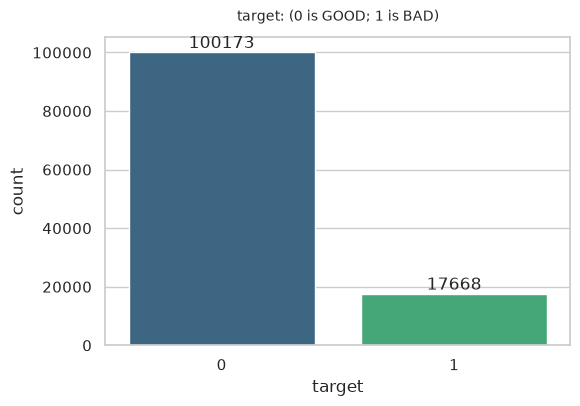

In [17]:
# Target Distribution Visualization
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_safe, x='target', hue='target', palette='viridis', ax=ax, legend=False)
    
# Add label numbers above each bar
for container in ax.containers: 
    ax.bar_label(container, fmt='%d')
        
ax.set_title('target: (0 is GOOD; 1 is BAD)', fontsize=10, pad=12)
    
# Save figure before show
fig.savefig('Target_Feature_Distribution.png', dpi=150, bbox_inches='tight')

# Show
plt.show()

<br>

---
# 2.0. **Data Preprocessing**:
**The Processing Pipeline**<br>
> 2.1. **Split Input-Output + List of Features to be Used** <br>
> 2.2. **Train-Valid-Test Split** <br>
> 2.3. **Feature Binning & Engineering Processing** <br>
> 2.4. **One-Hot Encoding** <br>
> 2.5. **Preprocessing Pipeline Function**

<br>

---
## **1.1. Split Input-Output + List of Features to be Used**:

In [18]:
from src.utils import (
    split_input_output, 
    split_train_test,
    serialize_data,
    deserialize_data,
)

In [19]:
features_to_selected = [
    'annual_inc',
    'collections_12_mths_ex_med',
    'delinq_2yrs',
    'dti',
    'earliest_cr_line',
    'emp_length',
    'home_ownership',
    'inq_last_6mths',
    'issue_d',
    'loan_amnt',
    'open_acc',
    'pub_rec',
    'purpose',
    'revol_bal',
    'revol_util',
    'term',
    'total_acc',
    'verification_status',
    'target'
]
# Perform and call the function
X, y = split_input_output(
    data=df_safe, 
    target_col='target',
    columns_to_keep=features_to_selected
)
# Serialize origin set
serialize_data(X, 'data/interim/X.pkl')
serialize_data(y, 'data/interim/y.pkl')

X shape: (117841, 18)
y shape: (117841,)
Data successfully serialized to data/interim/X.pkl
Data successfully serialized to data/interim/y.pkl


<br>

---
New Feature: `loan_to_income`

count    117841.000000
mean          0.207936
std           0.114614
min           0.000789
25%           0.117647
50%           0.192000
75%           0.284848
max           1.120000
Name: loan_to_income, dtype: float64

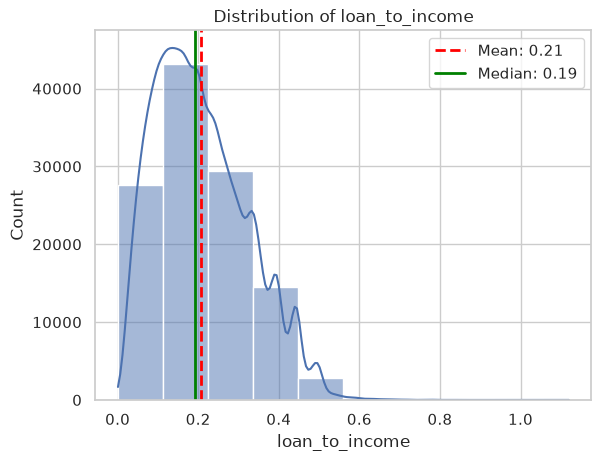

In [20]:
X['loan_to_income'] = X['loan_amnt'] / X['annual_inc']

display(X['loan_to_income'].describe())

sns.histplot(X['loan_to_income'], bins=10, kde=True)
plt.title(f"Distribution of loan_to_income")

# Calculate mean and median
mean_val = X['loan_to_income'].mean()
median_val = X['loan_to_income'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

<br>

---
New Feature: `open_acc_ratio`

count    117841.000000
mean          0.485504
std           0.179027
min           0.051282
25%           0.352941
50%           0.461538
75%           0.600000
max           1.000000
Name: open_acc_ratio, dtype: float64

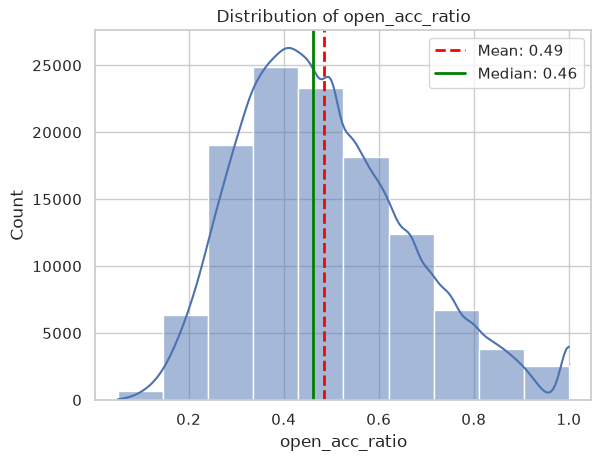

In [21]:
X['open_acc_ratio'] = X['open_acc'] / X['total_acc'].replace(0, np.nan)  # hindari div/0

display(X['open_acc_ratio'].describe())

sns.histplot(X['open_acc_ratio'], bins=10, kde=True)
plt.title(f"Distribution of open_acc_ratio")

# Calculate mean and median
mean_val = X['open_acc_ratio'].mean()
median_val = X['open_acc_ratio'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

<br>

---
New Feature: `revol_bal_to_income`

count    117841.000000
mean          0.233392
std           0.195196
min           0.000000
25%           0.102815
50%           0.193536
75%           0.314750
max           4.358165
Name: revol_bal_to_income, dtype: float64

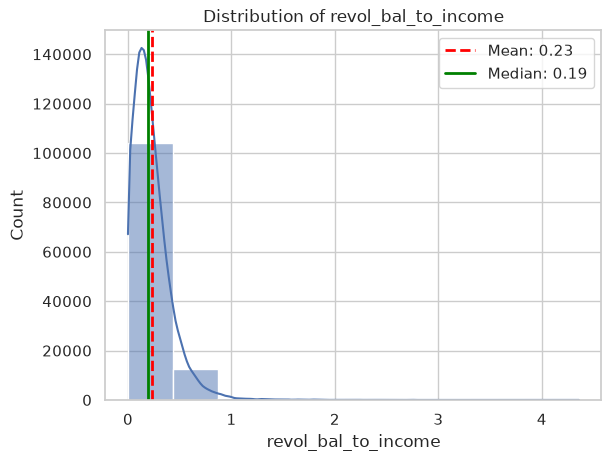

In [22]:
X['revol_bal_to_income'] = X['revol_bal'] / X['annual_inc']

display(X.revol_bal_to_income.describe())

sns.histplot(X.revol_bal_to_income, bins=10, kde=True)
plt.title(f"Distribution of revol_bal_to_income")

# Calculate mean and median
mean_val = X['revol_bal_to_income'].mean()
median_val = X['revol_bal_to_income'].median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

count    1.178410e+05
mean     1.552473e+04
std      1.943930e+04
min      0.000000e+00
25%      5.856000e+03
50%      1.133300e+04
75%      1.968700e+04
max      1.743266e+06
Name: revol_bal, dtype: float64

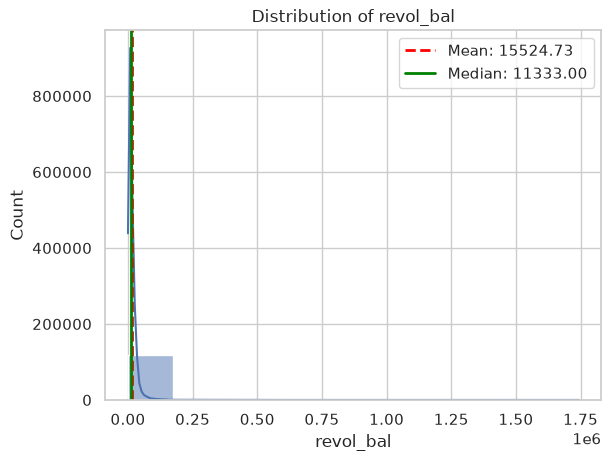

In [23]:
display(X.revol_bal.describe())

sns.histplot(X.revol_bal, bins=10, kde=True)
plt.title(f"Distribution of revol_bal")

# Calculate mean and median
mean_val = X.revol_bal.mean()
median_val = X.revol_bal.median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

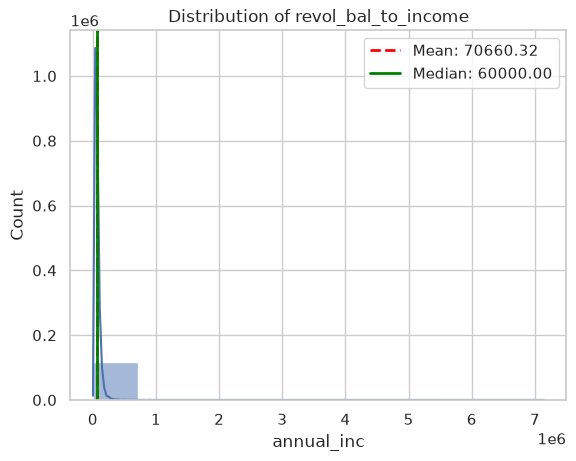

In [24]:
X.annual_inc.describe()

sns.histplot(X.annual_inc, bins=10, kde=True)
plt.title(f"Distribution of revol_bal_to_income")

# Calculate mean and median
mean_val = X.annual_inc.mean()
median_val = X.annual_inc.median()

# Add vertical lines for mean (red) and median (green)
plt.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')
plt.legend()
plt.show()

In [25]:
from src.utils import calculate_all_iv
tabel_iv = calculate_all_iv(
    X[['annual_inc', 'collections_12_mths_ex_med', 'delinq_2yrs', 'dti', 'inq_last_6mths', #'loan_amnt', 'open_acc', 'revol_bal',
       'open_acc_ratio', 'pub_rec', 'revol_bal_to_income', 'revol_util', 'total_acc', 'loan_to_income']], 
    target_col=y, num_bins=11)

tabel_iv

,Feature,Information Value (IV)
0,loan_to_income,0.085686
1,revol_util,0.050348
2,annual_inc,0.041406
3,inq_last_6mths,0.035946
4,dti,0.028330
5,revol_bal_to_income,0.015787
6,open_acc_ratio,0.009243
7,total_acc,0.002805
8,delinq_2yrs,0.000321
9,collections_12_mths_ex_med,0.000000


In [26]:
X.total_acc.describe()

count    117841.000000
mean         23.388116
std          11.261773
min           1.000000
25%          15.000000
50%          22.000000
75%          30.000000
max          99.000000
Name: total_acc, dtype: float64

In [27]:
X = X.drop(columns=['loan_amnt', 'revol_bal', 'open_acc',])

<br>

---
## **1.2. Train-Valid-Test Split**:

In [28]:
# ============================================================================
# STEP 1: SEPARATE FUTURE DATA (OOT TEST SET) BY CLEAN QUARTER CUTOFF
# ============================================================================
# Menggunakan Skema A: 2013Q1 penuh sebagai OOT Test (~3 bulan kalender)
# Catatan: Jika nanti ingin rentang lebih luas (~6 bulan / Skema B), silakan ubah ke '2012-10-01'
oot_cutoff_date = "2013-01-01"
print(f"Cut-off Date untuk OOT Test (Awal Kuartal 2013Q1): {oot_cutoff_date}")

# Buat mask berdasarkan batas tanggal kalender baku
is_oot = X['issue_d'] >= oot_cutoff_date

# Amankan data OOT Test (Data masa depan: 2013Q1 penuh)
X_test = X[is_oot].copy()
y_test = y[is_oot].copy()

# Amankan data Historis untuk basis Train dan Validation (2007 s/d 2012)
X_historical = X[~is_oot].copy()
y_historical = y[~is_oot].copy()

print(f"Step 1 Success:")
print(f" - Shape of Historical Data      : {X_historical.shape[0]} rows (2007 - 2012)")
print(f" - OOT Test Data Shape (Future)  : {X_test.shape[0]} rows (2013Q1)")
print(f"--------------------------------------------------------------------")

# ============================================================================
# STEP 2: SPLIT HISTORICAL DATA INTO TRAIN & VALID (STRATIFIED)
# ============================================================================
# Mempertahankan proporsi Validation sebesar ~10% dari total populasi awal
# Rasio di dalam data historis tetap menggunakan pendekatan 10/90
VAL_SIZE_WITHIN_HISTORICAL = 10 / 90

RANDOM_STATE = 42

print(f"Step 2: Splitting `X_historical` into `X_train` + `X_valid` (Stratified)")
X_train, X_valid, y_train, y_valid = split_train_test(
    X_historical, 
    y_historical,
    test_size=VAL_SIZE_WITHIN_HISTORICAL, 
    stratify=y_historical,
    seed=RANDOM_STATE
)

print(f"--------------------------------------------------------------------")
print(f"FINAL SPLIT REPORT:")
print(f"X_train shape : {X_train.shape} | Periode: {X_train['issue_d'].min().date()} s/d {X_train['issue_d'].max().date()}")
print(f"X_valid shape : {X_valid.shape} | Periode: {X_valid['issue_d'].min().date()} s/d {X_valid['issue_d'].max().date()}")
print(f"X_test shape  : {X_test.shape} | Periode: {X_test['issue_d'].min().date()} s/d {X_test['issue_d'].max().date()} (OOT)")

Cut-off Date untuk OOT Test (Awal Kuartal 2013Q1): 2013-01-01
Step 1 Success:
 - Shape of Historical Data      : 95360 rows (2007 - 2012)
 - OOT Test Data Shape (Future)  : 22481 rows (2013Q1)
--------------------------------------------------------------------
Step 2: Splitting `X_historical` into `X_train` + `X_valid` (Stratified)
--------------------------------------------------------------------
FINAL SPLIT REPORT:
X_train shape : (84764, 18) | Periode: 2007-08-01 s/d 2012-12-01
X_valid shape : (10596, 18) | Periode: 2007-08-01 s/d 2012-12-01
X_test shape  : (22481, 18) | Periode: 2013-01-01 s/d 2013-03-01 (OOT)


In [29]:
# Validate
print(len(X_train)/len(X))
print(len(X_valid)/len(X))
print(len(X_test)/len(X))

0.7193082203986728
0.08991777055523968
0.19077400904608752


In [30]:
print(f"y_train: {y_train.value_counts()}")
print(f"y_valid: {y_valid.value_counts()}")
print(f"y_test: {y_test.value_counts()}")

y_train: target
0    71846
1    12918
Name: count, dtype: int64
y_valid: target
0    8981
1    1615
Name: count, dtype: int64
y_test: target
0    19346
1     3135
Name: count, dtype: int64


In [31]:
# Train Fit
serialize_data(X_train, 'data/interim/X_train_raw.pkl')
serialize_data(y_train, 'data/interim/y_train.pkl')

# Validation set
serialize_data(X_valid, 'data/interim/X_valid_raw.pkl')
serialize_data(y_valid, 'data/interim/y_valid.pkl')

# Test set
serialize_data(X_test, 'data/interim/X_test_raw.pkl')
serialize_data(y_test, 'data/interim/y_test.pkl')

Data successfully serialized to data/interim/X_train_raw.pkl
Data successfully serialized to data/interim/y_train.pkl
Data successfully serialized to data/interim/X_valid_raw.pkl
Data successfully serialized to data/interim/y_valid.pkl
Data successfully serialized to data/interim/X_test_raw.pkl
Data successfully serialized to data/interim/y_test.pkl


<br>

---
## **1.3. Feature Binning Processing**:

In [32]:
# Import functions and classes from the binning module
from src.binning_v3 import (
    fit_binning, 
    transform_binning,
    binning_summary,
    binning_table,
)

# --- MAIN STEPS ---
# 1. FIT ON TRAINING DATA ONLY
# This step calculates edges for quantile columns (annual_inc, etc.) 
# based on the distribution of the training data only. This prevents data leakage.
print(f"Fitting binning using Train data...")
binning_artifacts = fit_binning(X_train.assign(y=y_train), target_col='y')

# 2. Show Summary (Audit Information Value & Status)
summary_df = binning_summary(binning_artifacts)
display(summary_df)

# IMPORTANT: Check the 'status' column. Everything should be 'OPTIMAL'.
# If it's 'INFEASIBLE', you should loosen the parameters in BINNING_FIT_PARAMS.

(CVXPY) Jul 15 03:37:58 AM: Encountered unexpected exception importing solver HIGHS:
ImportError('/home/gontommuhammad/miniconda3/envs/credit-risk_VENV/lib/python3.13/site-packages/highspy/_core.cpython-313-x86_64-linux-gnu.so: undefined symbol: _ZN5Highs13releaseMemoryEv')


Fitting binning using Train data...


,name,dtype,status,selected,n_bins,iv,js,gini,quality_score
0,annual_inc,numerical,OPTIMAL,True,10,0.036383,0.004533,0.105986,0.001556
1,dti,numerical,OPTIMAL,True,11,0.027031,0.003372,0.093529,0.000409
2,loan_to_income,numerical,OPTIMAL,True,11,0.095299,0.011805,0.168979,0.014854
3,revol_util,numerical,OPTIMAL,True,11,0.061789,0.007678,0.139202,0.024119
4,revol_bal_to_income,numerical,OPTIMAL,True,8,0.019374,0.002417,0.076902,0.001963
5,open_acc_ratio,numerical,OPTIMAL,True,7,0.009048,0.00113,0.053324,0.006994
6,inq_last_6mths,numerical,OPTIMAL,True,4,0.048903,0.006086,0.117945,0.161019
7,purpose,categorical,OPTIMAL,True,6,0.040308,0.005017,0.103371,0.078388
8,home_ownership,categorical,OPTIMAL,True,3,0.005054,0.000632,0.036107,0.007473


In [33]:
# 3. Check the binning details and WoE values for one of the features (example: annual_inc)
binning_table(binning_artifacts, 'annual_inc')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 28572.00)",6316,0.074513,5138,1178,0.186510,-0.243057,0.004783,0.000596
1,"[28572.00, 36836.00)",8415,0.099276,6884,1531,0.181937,-0.212624,0.004827,0.000602
2,"[36836.00, 43986.74)",8348,0.098485,6869,1479,0.177168,-0.180251,0.003404,0.000425
3,"[43986.74, 60606.00)",21866,0.257963,18309,3557,0.162673,-0.077428,0.001588,0.000199
4,"[60606.00, 66096.00)",5441,0.064190,4637,804,0.147767,0.03632,0.000084,0.000010
5,"[66096.00, 75328.50)",8273,0.097600,7094,1179,0.142512,0.078679,0.000588,0.000073
6,"[75328.50, 82718.00)",4555,0.053737,3929,626,0.137431,0.120887,0.000753,0.000094
7,"[82718.00, 92124.00)",5447,0.064261,4718,729,0.133835,0.151563,0.001400,0.000175
8,"[92124.00, 129449.50)",10219,0.120558,9048,1171,0.114590,0.328782,0.011602,0.001444
9,"[129449.50, inf)",5884,0.069416,5220,664,0.112848,0.346067,0.007355,0.000915


In [34]:
binning_table(binning_artifacts, 'dti')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 5.95)",9867,0.116406,8667,1200,0.121618,0.261298,0.007248,0.000903
1,"[5.95, 7.79)",5066,0.059766,4431,635,0.125345,0.226852,0.002840,0.000354
2,"[7.79, 9.19)",4612,0.054410,3986,626,0.135733,0.13529,0.000950,0.000119
3,"[9.19, 12.23)",11133,0.131341,9603,1530,0.137429,0.120905,0.001840,0.000230
4,"[12.23, 13.82)",6364,0.075079,5439,925,0.145349,0.055654,0.000228,0.000029
5,"[13.82, 16.03)",9086,0.107192,7754,1332,0.146599,0.045624,0.000220,0.000027
6,"[16.03, 17.95)",7647,0.090215,6451,1196,0.156401,-0.030651,0.000086,0.000011
7,"[17.95, 20.16)",8383,0.098898,6991,1392,0.166050,-0.102021,0.001066,0.000133
8,"[20.16, 21.91)",6004,0.070832,4955,1049,0.174717,-0.163343,0.001999,0.000250
9,"[21.91, 27.38)",11920,0.140626,9800,2120,0.177852,-0.184937,0.005124,0.000640


In [35]:
binning_table(binning_artifacts, 'loan_to_income')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.06)",7421,0.087549,6597,824,0.111036,0.364296,0.010213,1.269593e-03
1,"[0.06, 0.10)",9483,0.111875,8392,1091,0.115048,0.324281,0.010490,1.305579e-03
2,"[0.10, 0.13)",8801,0.103829,7721,1080,0.122713,0.25108,0.005991,7.469372e-04
3,"[0.13, 0.16)",8530,0.100632,7466,1064,0.124736,0.232421,0.005009,6.247075e-04
4,"[0.16, 0.19)",8789,0.103688,7631,1158,0.131756,0.169621,0.002811,3.509272e-04
5,"[0.19, 0.23)",11537,0.136107,9842,1695,0.146919,0.043073,0.000249,3.109187e-05
6,"[0.23, 0.26)",6368,0.075126,5403,965,0.151539,0.006678,0.000003,4.178511e-07
7,"[0.26, 0.29)",4563,0.053832,3741,822,0.180145,-0.200535,0.002319,2.893501e-04
8,"[0.29, 0.32)",4866,0.057406,3964,902,0.185368,-0.235509,0.003451,4.303253e-04
9,"[0.32, 0.37)",6225,0.073439,4934,1291,0.207390,-0.37517,0.011729,1.457599e-03


In [36]:
binning_table(binning_artifacts, 'revol_util')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 16.85)",9726,0.114742,8730,996,0.102406,0.45487,0.020200,0.002503
1,"[16.85, 27.35)",6516,0.076872,5802,714,0.109576,0.379172,0.009663,0.001201
2,"[27.35, 38.55)",8507,0.100361,7428,1079,0.126837,0.213319,0.004237,0.000529
3,"[38.55, 47.55)",8145,0.096090,7007,1138,0.139718,0.101734,0.000960,0.000120
4,"[47.55, 55.05)",7604,0.089708,6470,1134,0.149132,0.025522,0.000058,0.000007
5,"[55.05, 65.95)",12190,0.143811,10261,1929,0.158244,-0.044555,0.000290,0.000036
6,"[65.95, 75.45)",10505,0.123932,8700,1805,0.171823,-0.143141,0.002667,0.000333
7,"[75.45, 80.55)",5594,0.065995,4624,970,0.173400,-0.154184,0.001654,0.000207
8,"[80.55, 85.75)",5447,0.064261,4444,1003,0.184138,-0.227344,0.003590,0.000448
9,"[85.75, 92.65)",6075,0.071670,4897,1178,0.193909,-0.291099,0.006704,0.000835


In [37]:
binning_table(binning_artifacts, 'revol_bal_to_income')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.05)",10419,0.122918,9058,1361,0.130627,0.179525,0.003719,4.643103e-04
1,"[0.05, 0.13)",18614,0.219598,16054,2560,0.137531,0.120048,0.003034,3.790786e-04
2,"[0.13, 0.18)",12038,0.142018,10314,1724,0.143213,0.072952,0.000737,9.207993e-05
3,"[0.18, 0.23)",10697,0.126197,9061,1636,0.152940,-0.004178,0.000002,2.757578e-07
4,"[0.23, 0.30)",10431,0.123059,8833,1598,0.153197,-0.006161,0.000005,5.852092e-07
5,"[0.30, 0.38)",9078,0.107097,7555,1523,0.167768,-0.114376,0.001457,1.820732e-04
6,"[0.38, 0.54)",8641,0.101942,7061,1580,0.182849,-0.218741,0.005256,6.557460e-04
7,"[0.54, inf)",4846,0.057170,3910,936,0.193149,-0.286226,0.005162,6.430701e-04
8,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000e+00
9,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000e+00


In [38]:
binning_table(binning_artifacts, 'open_acc_ratio')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.30)",13053,0.153992,11254,1799,0.137823,0.117589,0.002043,0.000255
1,"[0.30, 0.41)",20353,0.240114,17486,2867,0.140864,0.092231,0.001978,0.000247
2,"[0.41, 0.47)",11401,0.134503,9689,1712,0.150162,0.017426,0.000041,0.000005
3,"[0.47, 0.58)",16872,0.199047,14227,2645,0.156769,-0.033433,0.000225,0.000028
4,"[0.58, 0.65)",7515,0.088658,6306,1209,0.160878,-0.064195,0.000374,0.000047
5,"[0.65, 0.78)",9621,0.113503,7992,1629,0.169317,-0.125429,0.001865,0.000233
6,"[0.78, inf)",5949,0.070183,4892,1057,0.177677,-0.183737,0.002523,0.000315
7,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
8,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.009048,0.001130


In [39]:
binning_table(binning_artifacts, 'inq_last_6mths')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",40651,0.479579,35503,5148,0.126639,0.215106,0.020573,0.002567
1,"[0.50, 1.50)",23255,0.274350,19534,3721,0.160009,-0.057739,0.000933,0.000117
2,"[1.50, 2.50)",12117,0.142950,9964,2153,0.177684,-0.183787,0.005143,0.000642
3,"[2.50, inf)",8741,0.103122,6845,1896,0.216909,-0.432131,0.022254,0.002760
4,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
5,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.048903,0.006086


In [40]:
binning_table(binning_artifacts, 'purpose')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[car, major_purchase]",5489,0.064756,4907,582,0.106030,0.416044,9.671137e-03,1.200248e-03
1,[credit_card],14034,0.165566,12347,1687,0.120208,0.274558,1.132846e-02,1.411627e-03
2,[home_improvement],5377,0.063435,4706,671,0.124791,0.231921,3.144430e-03,3.921753e-04
3,[debt_consolidation],44761,0.528066,37556,7205,0.160966,-0.064845,2.270864e-03,2.838083e-04
4,"[other, small_business]",10170,0.119980,8148,2022,0.198820,-0.322218,1.389292e-02,1.729141e-03
5,"[wedding, medical, moving, house, educational,...",4933,0.058197,4182,751,0.152240,0.001236,8.886555e-08,1.110819e-08
6,Special,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
7,Missing,0,0.000000,0,0,0.000000,0.0,0.000000e+00,0.000000e+00
Totals,,84764,1.000000,71846,12918,0.152400,,4.030790e-02,5.017011e-03


In [41]:
binning_table(binning_artifacts, 'home_ownership')

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[MORTGAGE],38847,0.458296,33312,5535,0.142482,0.078923,0.002777,0.000347
1,[OWN],6590,0.077745,5549,1041,0.157967,-0.042467,0.000142,0.000018
2,"[RENT, OTHER]",39327,0.463959,32985,6342,0.161263,-0.067045,0.002134,0.000267
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,84764,1.000000,71846,12918,0.152400,,0.005054,0.000632


In [42]:
# 3. TRANSFORM ALL SPLIT DATA
# Apply the previously fitted boundaries to the Train, Valid & Test data for fisrt analysis.
print(f"Transforming all set data first...")
X_train_binned = transform_binning(X_train, binning_artifacts)
X_valid_binned = transform_binning(X_valid, binning_artifacts)
X_test_binned = transform_binning(X_test, binning_artifacts)

# 4. SAVE THE ARTIFACT FOR PRODUCTION/AUDIT NEEDS
# Save these binning limits so that when predicting new data in the future, we can use the exact same limits.
import joblib

joblib.dump(binning_artifacts, 'binning_artifacts.pkl')
print(f"The binning process is complete and the artifact has been saved!")

Transforming all set data first...
The binning process is complete and the artifact has been saved!


In [43]:
from src.binning import evaluate_bad_rate_monotonicity

report = evaluate_bad_rate_monotonicity(
    df=X_train_binned.assign(y=y_train), 
    bin_col='total_acc_group', 
    target_col='y'
)
report

,total_acc_group,count,bad_count,bad_rate,is_monotonic_increasing,is_monotonic_decreasing
0,less_10,10123,1695,0.167440,False,False
1,10_to_20,29280,4481,0.153040,False,False
2,20_to_30,25883,3847,0.148630,False,False
3,30_to_40,13018,1917,0.147258,False,False
4,greater_40,6460,978,0.151393,False,False


In [44]:
report = evaluate_bad_rate_monotonicity(
    df=X_valid_binned.assign(y=y_valid), 
    bin_col='total_acc_group', 
    target_col='y'
)
report

,total_acc_group,count,bad_count,bad_rate,is_monotonic_increasing,is_monotonic_decreasing
0,less_10,1279,215,0.168100,False,False
1,10_to_20,3682,577,0.156708,False,False
2,20_to_30,3285,476,0.144901,False,False
3,30_to_40,1584,245,0.154672,False,False
4,greater_40,766,102,0.133159,False,False


In [45]:
report = evaluate_bad_rate_monotonicity(
    df=X_test_binned.assign(y=y_test), 
    bin_col='total_acc_group', 
    target_col='y'
)
report

,total_acc_group,count,bad_count,bad_rate,is_monotonic_increasing,is_monotonic_decreasing
0,less_10,1428,201,0.140756,False,False
1,10_to_20,7198,1073,0.149069,False,False
2,20_to_30,7537,1053,0.139711,False,False
3,30_to_40,4120,529,0.128398,False,False
4,greater_40,2198,279,0.126934,False,False


In [46]:
def summarize_features_chi2(df: pd.DataFrame, title: str, features: list, target_col: str) -> pd.DataFrame:
    from scipy.stats import chi2_contingency
    """
    Summarizes the Chi-Square statistical test and monotonicity trend to the feature level (1 row per 1 feature).
    """
    summary_list = []
    
    for feat in features:
        # 1. Buat crosstab untuk uji Chi-Square
        ct = pd.crosstab(df[feat], df[target_col])
        
        # Ensure the contingency table is valid (minimum 2x2)
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p_val, dof, _ = chi2_contingency(ct)
        else:
            chi2, p_val, dof = None, None, None
            
        # 2. Calculate aggregate statistics for bad rates
        agg = df.groupby(feat, observed=True)[target_col].agg(['size', 'sum'])
        agg['bad_rate'] = agg['sum'] / agg['size']
        
        # 3. Check the monotonicity of the bad rate from the first to the last bin
        # Use .dropna() on bad_rate to check for empty bins.
        bad_rate_series = agg['bad_rate'].dropna()
        is_inc = bad_rate_series.is_monotonic_increasing
        is_dec = bad_rate_series.is_monotonic_decreasing
        
        # Naming trends for easy reading
        if is_inc:
            trend = 'Increasing'
        elif is_dec:
            trend = 'Decreasing'
        else:
            trend = 'Not Monotonic'
        
        # 4. Enter into dictionary per feature
        summary_list.append({
            'feature': feat,
            'num_of_bins': ct.shape[0],
            'chi_square': chi2,
            'p-value': p_val,
            'DoF': dof,
            'min_bad_rate': agg['bad_rate'].min(),
            'max_bad_rate': agg['bad_rate'].max(),
            'is_monotonic_inc': is_inc,
            'is_monotonic_dec': is_dec,
            'trend': trend
        })
    
    # Convert list to DataFrame
    summary_list_df = pd.DataFrame(summary_list)
    
    # --- Summary Documentation ---
    num_features = summary_list_df.shape[0]
    num_significant = summary_list_df[summary_list_df['p-value'] < 0.05].shape[0]
    num_not_monotonic = summary_list_df[summary_list_df['trend'] == 'Not Monotonic'].shape[0]

    print(f"# {title}:")
    print(f"Number of Features: {num_features}")
    print(f"Number of Features with `p-value` below 0.05: {num_significant}")
    print(f"Number of Features with `Not Monotonic` trend: {num_not_monotonic}")
    
    return summary_list_df


# --- RUN ---
list_of_cat_features = X_train_binned.select_dtypes(
    # make sure all object types 
    # or str types are converted to category first
    include=['category']).columns.tolist()

# Call the summary function
chi2_summary = summarize_features_chi2(
    df=X_train_binned.assign(y=y_train), 
    title='Training Set',
    features=X_train_binned.columns, 
    target_col='y'
)

# You can sort by smallest `p-value` / largest `chi_square` 
# to see which features are most statistically influential
chi2_summary.sort_values(by='p-value', ascending=False)

# Training Set:
Number of Features: 15
Number of Features with `p-value` below 0.05: 15
Number of Features with `Not Monotonic` trend: 11


,feature,num_of_bins,chi_square,p-value,DoF,min_bad_rate,max_bad_rate,is_monotonic_inc,is_monotonic_dec,trend
4,total_acc_group,5,23.383642,1.061282e-04,4,0.147258,0.167440,False,False,Not Monotonic
2,credit_age_group,3,47.806047,4.159574e-11,2,0.142771,0.177398,False,True,Decreasing
14,home_ownership_bin,3,55.079561,1.095533e-12,2,0.142482,0.161263,False,False,Not Monotonic
3,emp_length_group,5,69.404234,3.032187e-14,4,0.145397,0.201722,False,False,Not Monotonic
5,has_derogatory,2,70.954302,3.655957e-17,1,0.147834,0.176156,False,True,Decreasing
11,open_acc_ratio_bin,7,100.299214,2.173317e-19,6,0.137823,0.177677,False,False,Not Monotonic
1,verification_status,2,152.529961,4.852888e-35,1,0.133818,0.164928,True,False,Increasing
10,revol_bal_to_income_bin,8,218.951143,1.101589e-43,7,0.130627,0.193149,False,False,Not Monotonic
7,dti_bin,11,296.889749,7.063838e-58,10,0.121618,0.195002,False,False,Not Monotonic
6,annual_inc_bin,10,385.184511,1.980436e-77,9,0.112848,0.186510,False,False,Not Monotonic


In [47]:
# Call the summary function
chi2_summary = summarize_features_chi2(
    df=X_valid_binned.assign(y=y_valid),
    title='Validation Set',
    features=X_train_binned.columns, 
    target_col='y'
)
chi2_summary.sort_values(by='p-value', ascending=False)

# Validation Set:
Number of Features: 15
Number of Features with `p-value` below 0.05: 12
Number of Features with `Not Monotonic` trend: 11


,feature,num_of_bins,chi_square,p-value,DoF,min_bad_rate,max_bad_rate,is_monotonic_inc,is_monotonic_dec,trend
3,emp_length_group,5,6.030735,1.968647e-01,4,0.143502,0.190751,False,False,Not Monotonic
4,total_acc_group,5,6.657763,1.551175e-01,4,0.133159,0.168100,False,False,Not Monotonic
10,revol_bal_to_income_bin,8,13.934654,5.235588e-02,7,0.130827,0.179074,False,False,Not Monotonic
11,open_acc_ratio_bin,7,14.825442,2.165871e-02,6,0.136969,0.179647,False,False,Not Monotonic
14,home_ownership_bin,3,12.566840,1.867005e-03,2,0.139329,0.165076,False,False,Not Monotonic
7,dti_bin,11,39.747640,1.876907e-05,10,0.110379,0.191201,False,False,Not Monotonic
5,has_derogatory,2,19.239354,1.153116e-05,1,0.145724,0.188060,False,True,Decreasing
2,credit_age_group,3,27.287049,1.187661e-06,2,0.134996,0.220302,False,True,Decreasing
1,verification_status,2,31.570820,1.922975e-08,1,0.128120,0.168414,True,False,Increasing
13,purpose_bin,6,54.460369,1.685456e-10,5,0.108621,0.187162,False,False,Not Monotonic


In [48]:
# Call the summary function
chi2_summary = summarize_features_chi2(
    df=X_test_binned.assign(y=y_test),
    title='Test Set',
    features=X_train_binned.columns, 
    target_col='y'
)
chi2_summary.sort_values(by='p-value', ascending=False)

# Test Set:
Number of Features: 15
Number of Features with `p-value` below 0.05: 14
Number of Features with `Not Monotonic` trend: 12


,feature,num_of_bins,chi_square,p-value,DoF,min_bad_rate,max_bad_rate,is_monotonic_inc,is_monotonic_dec,trend
5,has_derogatory,2,0.251056,6.163324e-01,1,0.138816,0.141765,False,True,Decreasing
4,total_acc_group,5,12.637451,1.319009e-02,4,0.126934,0.149069,False,False,Not Monotonic
3,emp_length_group,5,19.270294,6.954282e-04,4,0.133441,0.189873,False,False,Not Monotonic
2,credit_age_group,3,34.297285,3.568117e-08,2,0.124467,0.151811,False,False,Not Monotonic
10,revol_bal_to_income_bin,8,50.525236,1.139061e-08,7,0.115888,0.163658,False,False,Not Monotonic
11,open_acc_ratio_bin,7,52.995359,1.175818e-09,6,0.117239,0.168919,False,False,Not Monotonic
14,home_ownership_bin,3,65.040649,7.526662e-15,2,0.122366,0.161123,False,False,Not Monotonic
9,revol_util_bin,11,93.054325,1.325108e-15,10,0.076923,0.196144,False,False,Not Monotonic
1,verification_status,2,73.567923,9.723201e-18,1,0.111892,0.153768,True,False,Increasing
12,inq_last_6mths_bin,4,91.591673,9.969084e-20,3,0.119910,0.177694,False,False,Not Monotonic


In [49]:
from src.population_stability_index import psi_report
print(psi_report(X_train_binned, X_valid_binned, bin_columns=X_train_binned.columns))

                    feature  psi_total verdict
0        open_acc_ratio_bin   0.001195  Stable
1        loan_to_income_bin   0.001138  Stable
2   revol_bal_to_income_bin   0.001035  Stable
3                   dti_bin   0.000881  Stable
4            annual_inc_bin   0.000633  Stable
5            revol_util_bin   0.000609  Stable
6           total_acc_group   0.000414  Stable
7                      term   0.000239  Stable
8          credit_age_group   0.000190  Stable
9               purpose_bin   0.000161  Stable
10      verification_status   0.000135  Stable
11       inq_last_6mths_bin   0.000088  Stable
12           has_derogatory   0.000073  Stable
13         emp_length_group   0.000059  Stable
14       home_ownership_bin   0.000018  Stable


In [50]:
print(psi_report(X_train_binned, X_test_binned, bin_columns=X_train_binned.columns))

                    feature  psi_total                        verdict
0               purpose_bin   0.196490  Moderate shift -- investigate
1            revol_util_bin   0.129503  Moderate shift -- investigate
2                   dti_bin   0.113545  Moderate shift -- investigate
3   revol_bal_to_income_bin   0.105605  Moderate shift -- investigate
4        loan_to_income_bin   0.094496                         Stable
5            annual_inc_bin   0.052334                         Stable
6           total_acc_group   0.050623                         Stable
7          emp_length_group   0.040703                         Stable
8          credit_age_group   0.040507                         Stable
9        home_ownership_bin   0.024457                         Stable
10           has_derogatory   0.019227                         Stable
11       open_acc_ratio_bin   0.016819                         Stable
12      verification_status   0.015860                         Stable
13       inq_last_6m

In [51]:
X_train_binned.info()

<class 'pandas.DataFrame'>
Index: 84764 entries, 1006175 to 1367503
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   term                     84764 non-null  category
 1   verification_status      84764 non-null  category
 2   credit_age_group         84764 non-null  category
 3   emp_length_group         84764 non-null  category
 4   total_acc_group          84764 non-null  category
 5   has_derogatory           84764 non-null  category
 6   annual_inc_bin           84764 non-null  category
 7   dti_bin                  84764 non-null  category
 8   loan_to_income_bin       84764 non-null  category
 9   revol_util_bin           84764 non-null  category
 10  revol_bal_to_income_bin  84764 non-null  category
 11  open_acc_ratio_bin       84764 non-null  category
 12  inq_last_6mths_bin       84764 non-null  category
 13  purpose_bin              84764 non-null  category
 14  home_ownership

<br>

### **Prepare Set for Tree-based Models**

In [53]:
# Tree-based Set
serialize_data(X_train_binned, 'data/processed/tree-based/X_train_tb.pkl')
serialize_data(X_valid_binned, 'data/processed/tree-based/X_valid_tb.pkl')
serialize_data(X_test_binned, 'data/processed/tree-based/X_test_tb.pkl')

Data successfully serialized to data/processed/tree-based/X_train_tb.pkl
Data successfully serialized to data/processed/tree-based/X_valid_tb.pkl
Data successfully serialized to data/processed/tree-based/X_test_tb.pkl


<br>

---
## **1.5. One-Hot Encoding**:

<br>

**List of Business Baseline**:

In [ ]:
# List of baseline columns that will be used as the zero (0) risk point by Logistic Regression
business_baselines = [
    # Manual Binning
    'credit_age_group_5_15',
    'emp_length_group_New_Employee',
    'has_derogatory_No_Derogatory',
    'term_36_months',
    'total_acc_group_10_to_20',
    'verification_status_Verified',
    # OptBinning
    'annual_inc_bin_43986p74_to_60606',
    'dti_bin_21p91_to_27p38',
    'home_ownership_bin_OTHER_RENT',
    'inq_last_6mths_bin_less_0p5',
    'loan_to_income_bin_0p19_to_0p23',
    'open_acc_ratio_bin_0p3_to_0p41',
    'purpose_bin_debt_consolidation',
    'revol_bal_to_income_bin_0p05_to_0p13',
    'revol_util_bin_55p05_to_65p95',
]

In [ ]:
X_train_binned['home_ownership_bin'].value_counts()

In [ ]:
X_train_binned.columns

<br>

**Build Function for One-Hot Encoder**:

In [ ]:
# Create function for encoder
def get_ohe_encoder(data):
    """
    Initializes and fits a OneHotEncoder on the provided data.
    
    Parameters:
    data -- DataFrame or array-like, the input data to be encoded
    
    Returns:
    encoder -- Fitted OneHotEncoder object
    """
    from sklearn.preprocessing import OneHotEncoder
    # Initialize OneHotEncoder with specified parameters
    encoder = OneHotEncoder(
        drop=None,
        sparse_output=False, 
        handle_unknown='ignore'
    )
    # Fit encoder to training data
    encoder.fit(
        data
    )
    # Return the fitted encoder
    return encoder


# Function for transformation
def transform_cat(data, encoder, baselines_to_drop=None):
    """
    Transform categorical data using the provided encoder.

    Parameters:
    data (pd.DataFrame): The categorical data to transform.
    encoder (OneHotEncoder): The fitted encoder.

    Returns:
    pd.DataFrame: The transformed data as a DataFrame with the appropriate column names and index.
    """
    # Transform the categorical data using the fitted encoder
    transformed_data = pd.DataFrame(
        encoder.transform(data), 
        # Get feature names from encoder and use them as columns
        columns=encoder.get_feature_names_out(data.columns),
        # Keep the original index of the data
        index=data.index
    )

    # Manual dropping process if list baselines are given
    if baselines_to_drop is not None:
        # Use list comprehension to avoid errors if a column happens to be missing from the testing data
        cols_to_drop = [col for col in baselines_to_drop if col in transformed_data.columns]
        transformed_data = transformed_data.drop(columns=cols_to_drop)
        
    # Return the transformed data
    return transformed_data

In [ ]:
# Get the encoder
encoder = get_ohe_encoder(
    X_train_binned
)
# Transform categorical
X_train_bin_encoded = transform_cat(
    X_train_binned, encoder,
    baselines_to_drop=business_baselines
)
display(X_train_bin_encoded)

# Validate
print(f"Original shape : {X_train_binned.shape}")
print(f"Encoded shape  : {X_train_bin_encoded.shape}")

<br>

---
## **1.7. Preprocessing Function for Validation & Test Set**:

<br>

**Build a Function for Preprocessing**:

In [ ]:
def preprocessing(
    data, 
    binning_artifacts, 
    encoder, 
    business_baselines):

    # Make a copy so as not to modify the original DataFrame (X) directly
    data_processed = data.copy()
    
    # 1. Feature Grouping Processing
    data_binned = transform_binning(
        data_processed, binning_artifacts
    )
    # # 2. Numerical & Categorical
    # data_num, data_cat = split_num_cat(
    #     data_binned
    # )
    # 3. OHE Transformation
    data_bin_encoded = transform_cat(
        data_binned, encoder, 
        baselines_to_drop=business_baselines
    )
    # # 4. Concatenate
    # data_concated = concat_data(
    #     data_num, 
    #     data_cat_encoded
    # )
    # 5. Sorted columns
    data_bin_encoded = data_bin_encoded[sorted(data_bin_encoded.columns)]
    
    return data_bin_encoded

<br>

---
* **X_train**:

In [ ]:
X_train_check = preprocessing(
    X_train, 
    binning_artifacts, 
    encoder, 
    business_baselines
)
print(f"\nOriginal Data shape    :", X_train.shape)
print(f"Transformed Data shape :", X_train_check.shape)

X_train_check.describe().round(4)

In [ ]:
X_train_bin_encoded = X_train_bin_encoded[sorted(X_train_bin_encoded.columns)]
X_train_bin_encoded.describe().round(4)

In [ ]:
X_train_bin_encoded.shape

<br>

---
* **X_valid**:

In [ ]:
X_valid_bin_encoded = preprocessing(
    X_valid, 
    binning_artifacts, 
    encoder, 
    business_baselines
)
print(f"\nOriginal Data shape    :", X_valid.shape)
print(f"Transformed Data shape :", X_valid_bin_encoded.shape)

X_valid_bin_encoded.describe().round(4)

<br>

---
* **X_test**:

In [ ]:
X_test_bin_encoded = preprocessing(
    X_test, 
    binning_artifacts, 
    encoder, 
    business_baselines
)
print(f"\nOriginal Data shape    :", X_test.shape)
print(f"Transformed Data shape :", X_test_bin_encoded.shape)

X_test_bin_encoded.describe().round(4)

<br>

---
* **Final check**:

In [ ]:
X_train_bin_encoded.isna().sum()[X_train_bin_encoded.isna().sum() > 0]

In [ ]:
X_valid_bin_encoded.isna().sum()[X_valid_bin_encoded.isna().sum() > 0]

In [ ]:
X_test_bin_encoded.isna().sum()[X_test_bin_encoded.isna().sum() > 0]

In [ ]:
print(f"X_train_clean :", X_train_bin_encoded.shape)
print(f"X_valid_clean :", X_valid_bin_encoded.shape)
print(f"X_test_clean  :", X_test_bin_encoded.shape)

In [ ]:
print(f"y_train   :", y_train.shape)
print(f"y_valid   :", y_valid.shape)
print(f"y_test    :", y_test.shape)

In [ ]:
(X_train_bin_encoded.shape[0] + X_valid_bin_encoded.shape[0] + X_test_bin_encoded.shape[0]) == X.shape[0]

<br>

---
* **Features check**:

In [ ]:
from src.utils import compute_vif
compute_vif(X_train_bin_encoded, target_col=None)

In [ ]:
from sklearn.feature_selection import mutual_info_classif
# Mutual information measures the dependency between a feature and its target.
mi_scores = mutual_info_classif(
    X_train_bin_encoded, 
    y_train,
    discrete_features='auto'
)
mi_scores = pd.Series(
    mi_scores, 
    index=X_train_bin_encoded.columns
)

# Sort Feature Score
mi_scores = mi_scores.sort_values(
    ascending=False
)

pd.set_option('display.max_rows', None)
mi_scores

# selected_features = mi_scores[mi_scores > 0.01].index

# X_selected = X[selected_features]

<br>

---
* **Serialize Data set for Logistic Regression**:

In [ ]:
# LogReg Set
serialize_data(X_train_bin_encoded, 'data/processed/logreg/X_train_lr.pkl')
serialize_data(X_valid_bin_encoded, 'data/processed/logreg/X_valid_lr.pkl')
serialize_data(X_test_bin_encoded, 'data/processed/logreg/X_test_lr.pkl')